# Cataract Detection - MobileNetV2 Training

This notebook trains a MobileNetV2 image classifier for cataract detection using a pre-split, preprocessed image dataset. It saves the trained MobileNetV2 model and label map, then evaluates the model with sklearn metrics including a classification report and confusion matrix.

## Expected dataset layout

Set `DATASET_DIR` to your dataset root. The notebook expects your 70/15/15 split to already exist on disk:

```text
cataract_dataset/
  train/
    cataract/
    normal/
  validation/    # val/ also works
    cataract/
    normal/
  test/
    cataract/
    normal/
```

The notebook reads your prepared train, validation, and test folders directly.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path
import json
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [3]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

# Change this path if your pre-split dataset lives somewhere else.
DATASET_DIR = Path("/content/drive/MyDrive/cataract_dataset")
TRAIN_DIR = DATASET_DIR / 'train'
VAL_DIR = DATASET_DIR / 'validation'
if not VAL_DIR.exists():
    VAL_DIR = DATASET_DIR / 'valid'
if not VAL_DIR.exists():
    VAL_DIR = DATASET_DIR / 'val'
TEST_DIR = DATASET_DIR / 'test'

MODEL_DIR = Path('/content/drive/MyDrive/mobilenetv2_model')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / 'cataract_mobilenetv2.keras'
LABELS_PATH = MODEL_DIR / 'cataract_labels.json'

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f'Dataset directory not found: {DATASET_DIR.resolve()}\n'
        'Update DATASET_DIR to your cataract_dataset folder.'
    )

for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not split_dir.exists():
        raise FileNotFoundError(f'Missing split folder: {split_dir.resolve()}')

class_names = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
if len(class_names) < 2:
    raise ValueError('Expected at least 2 class folders inside the train split.')

print('Dataset:', DATASET_DIR.resolve())
print('Train split:', TRAIN_DIR.resolve())
print('Validation split:', VAL_DIR.resolve())
print('Test split:', TEST_DIR.resolve())
print('Classes:', class_names)

Dataset: /content/drive/MyDrive/cataract_dataset
Train split: /content/drive/MyDrive/cataract_dataset/train
Validation split: /content/drive/MyDrive/cataract_dataset/valid
Test split: /content/drive/MyDrive/cataract_dataset/test
Classes: ['cataract', 'normal']


In [4]:
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
)

val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False,
)

# Keep the class order that Keras used and save it for chatbot inference.
class_names = train_ds.class_names
num_classes = len(class_names)
LABELS_PATH.write_text(json.dumps({'class_names': class_names}, indent=2))
print('Class index map:', {i: name for i, name in enumerate(class_names)})

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 1634 files belonging to 2 classes.
Found 350 files belonging to 2 classes.
Found 352 files belonging to 2 classes.
Class index map: {0: 'cataract', 1: 'normal'}


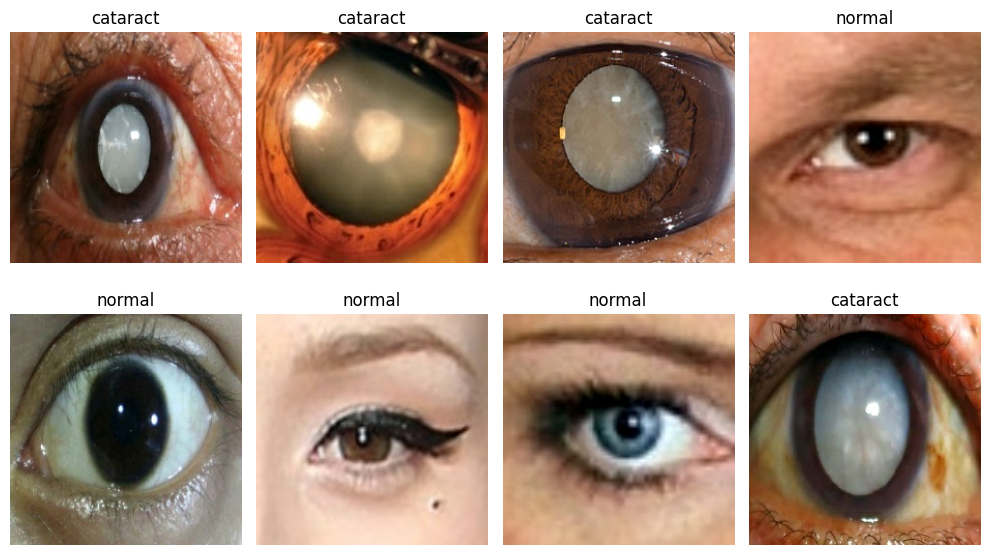

In [5]:
plt.figure(figsize=(10, 6))
for images, labels in train_ds.take(1):
    for i in range(min(8, images.shape[0])):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[int(labels[i])])
        plt.axis('off')
plt.tight_layout()

In [6]:
def compute_class_weights(dataset, class_count):
    counts = np.zeros(class_count, dtype=np.int64)
    for _, labels in dataset.unbatch():
        counts[int(labels.numpy())] += 1
    total = counts.sum()
    weights = {i: total / (class_count * count) for i, count in enumerate(counts) if count > 0}
    return counts, weights

class_counts, class_weight = compute_class_weights(train_ds, num_classes)
print('Training image counts:', dict(zip(class_names, class_counts.tolist())))
print('Class weights:', class_weight)

Training image counts: {'cataract': 817, 'normal': 817}
Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [7]:
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SIZE + (3,),
)
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)

outputs = layers.Dense(num_classes, activation='softmax', name='class_probabilities')(x)
loss = 'sparse_categorical_crossentropy'
metrics = ['accuracy']

model = keras.Model(inputs, outputs, name='cataract_mobilenetv2')
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=loss,
    metrics=metrics,
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "cataract_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
)

model.save(MODEL_PATH)
print('Saved model to:', MODEL_PATH.resolve())
print('Saved labels to:', LABELS_PATH.resolve())

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9635 - loss: 0.0928
Epoch 1: val_accuracy improved from None to 0.95714, saving model to content/drive/MyDrive/mobilenetv2_model/cataract_mobilenetv2.keras

Epoch 1: finished saving model to content/drive/MyDrive/mobilenetv2_model/cataract_mobilenetv2.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step - accuracy: 0.9663 - loss: 0.0924 - val_accuracy: 0.9571 - val_loss: 0.1191 - learning_rate: 0.0010
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9653 - loss: 0.0897
Epoch 2: val_accuracy did not improve from 0.95714
52/52 ━━━━━━━━━━━━━━━━━━━━ 195s 3s/step - accuracy: 0.9670 - loss: 0.0886 - val_accuracy: 0.9571 - val_loss: 0.1220 - learning_rate: 0.0010
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9667 - loss: 0.0808
Epoch 3: val_accuracy improved from 0.95714 to 0.96000, saving model to content/drive/MyDrive/mobilenetv2_model/cataract_mobilenetv2.keras

Epoch 3: finished saving model to content/

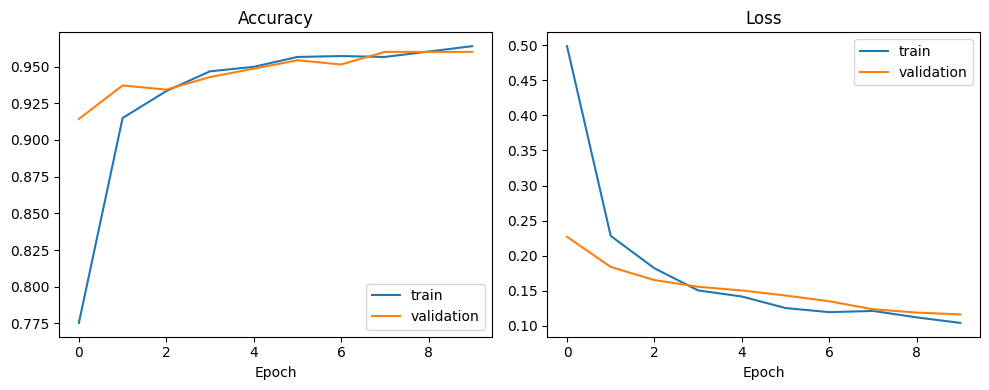

In [9]:
history_df = {
    key: [float(v) for v in values]
    for key, values in history.history.items()
}
(MODEL_DIR / 'mobilenetv2_training_history.json').write_text(json.dumps(history_df, indent=2))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()

11/11 ━━━━━━━━━━━━━━━━━━━━ 53s 5s/step - accuracy: 0.9688 - loss: 0.1013
Test loss: 0.1013
Test accuracy: 0.9688
Sklearn metrics:
Accuracy:  0.9688
Precision: 0.9688
Recall:    0.9688
F1 score:  0.9687
ROC AUC:   0.9931

Classification report:
              precision    recall  f1-score   support

    cataract       0.97      0.97      0.97       176
      normal       0.97      0.97      0.97       176

    accuracy                           0.97       352
   macro avg       0.97      0.97      0.97       352
weighted avg       0.97      0.97      0.97       352

Confusion matrix:
[[170   6]
 [  5 171]]


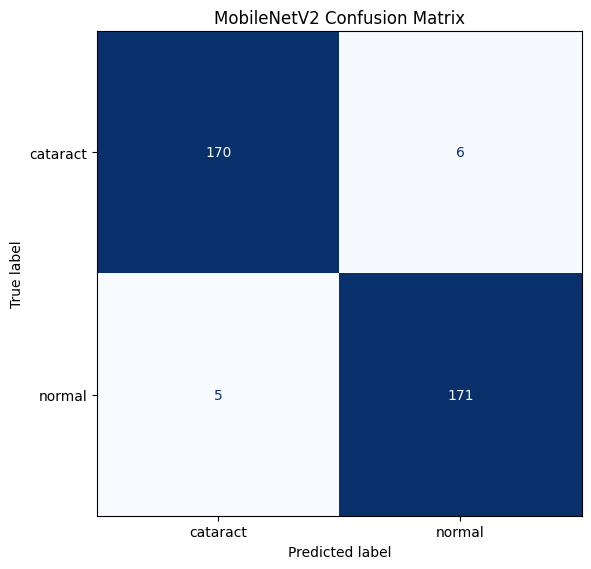

In [10]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

y_true = []
y_pred = []
y_score = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())
    y_score.extend(preds.tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

print('Sklearn metrics:')
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1 score:  {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")

try:
    if num_classes == 2:
        auc = roc_auc_score(y_true, y_score[:, 1])
    else:
        auc = roc_auc_score(y_true, y_score, multi_class='ovr', average='weighted')
    print(f'ROC AUC:   {auc:.4f}')
except ValueError as exc:
    print(f'ROC AUC unavailable: {exc}')

print('\nClassification report:')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
print('Confusion matrix:')
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
ax.set_title('MobileNetV2 Confusion Matrix')
plt.tight_layout()

## Optional fine-tuning

If the validation metrics look stable, unfreeze the last MobileNetV2 layers and train for a few more epochs with a very small learning rate. For a strict 10-epoch run, skip this section.

In [11]:
# base_model.trainable = True
# for layer in base_model.layers[:-30]:
#     layer.trainable = False
#
# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=1e-5),
#     loss=loss,
#     metrics=metrics,
# )
# fine_tune_history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=3,
#     class_weight=class_weight,
#     callbacks=callbacks,
# )
# model.save(MODEL_PATH)

## Upload inference helper

Use the saved MobileNetV2 model for uploaded images. The preprocessing layer is inside the model graph, so the helper only loads and batches the image before prediction.

In [7]:
def predict_uploaded_image(image_path, model_path=MODEL_PATH, labels_path=LABELS_PATH):
    loaded_model = keras.models.load_model(model_path)
    labels = json.loads(Path(labels_path).read_text())['class_names']

    img = keras.utils.load_img(image_path, target_size=IMG_SIZE)
    arr = keras.utils.img_to_array(img)
    batch = np.expand_dims(arr, axis=0)
    preds = loaded_model.predict(batch, verbose=0)

    class_idx = int(np.argmax(preds[0]))
    confidence = float(preds[0][class_idx])

    return {
        'label': labels[class_idx],
        'confidence': round(confidence, 4),
        'class_index': class_idx,
    }

img_path =  Path('/content/drive/MyDrive/sampleimages/sample3.jpg')

result = predict_uploaded_image(img_path)
print('Prediction result:', result)

# Example after training:
# predict_uploaded_image('path/to/uploaded_eye_image.jpg')

Prediction result: {'label': 'cataract', 'confidence': 0.9947, 'class_index': 0}
